In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
dtype = {
    'TAIL_NUM': str,
    'CANCELLATION_REASON': str,
    'AIRLINE': str,
    'ORIGIN_AIRPORT': str,
    'DESTINATION_AIRPORT': str
}

df_full = pd.read_csv('../data/raw/flights.csv', dtype=dtype, low_memory=False)
df = df_full.sample(n=500000, random_state=42).reset_index(drop=True)
del df_full 

print(df.shape)
print(df.columns.tolist())

(500000, 31)
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']


In [2]:
print(df.isnull().sum().sort_values(ascending=False).head(15))
print(df.dtypes)

CANCELLATION_REASON    492260
WEATHER_DELAY          408455
LATE_AIRCRAFT_DELAY    408455
AIRLINE_DELAY          408455
SECURITY_DELAY         408455
AIR_SYSTEM_DELAY       408455
AIR_TIME                 9016
ARRIVAL_DELAY            9016
ELAPSED_TIME             9016
WHEELS_ON                7965
TAXI_IN                  7965
ARRIVAL_TIME             7965
TAXI_OUT                 7667
WHEELS_OFF               7667
DEPARTURE_DELAY          7385
dtype: int64
YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
TAIL_NUMBER             object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE  

In [3]:
print(f"before: {len(df)}")
df = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)].copy()
print(f"after: {len(df)}")
df['IS_DELAYED'] = (df['DEPARTURE_DELAY'] > 15).astype(int)

print(f"delay rate: {df['IS_DELAYED'].mean():.3f}")
print(f"on-time: {(df['IS_DELAYED']==0).sum()}")
print(f"delayed: {(df['IS_DELAYED']==1).sum()}")

before: 500000
after: 490984
delay rate: 0.178
on-time: 403834
delayed: 87150


In [4]:

df['DATE'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']])
df['SCHED_DEP_HOUR'] = (df['SCHEDULED_DEPARTURE'] // 100) % 24
df = df.sort_values('DATE').reset_index(drop=True)

print(df['DATE'].min(), df['DATE'].max())
print(f"hour range: {df['SCHED_DEP_HOUR'].min()} to {df['SCHED_DEP_HOUR'].max()}")

2015-01-01 00:00:00 2015-12-31 00:00:00
hour range: 0 to 23


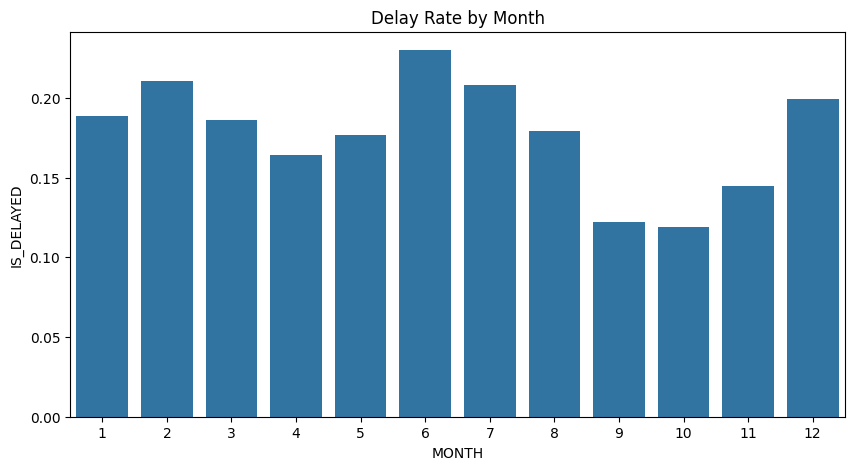

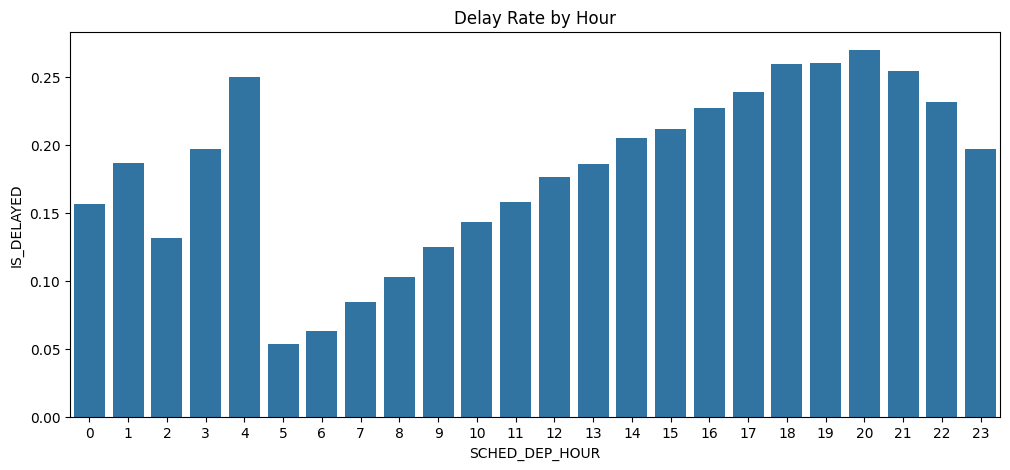

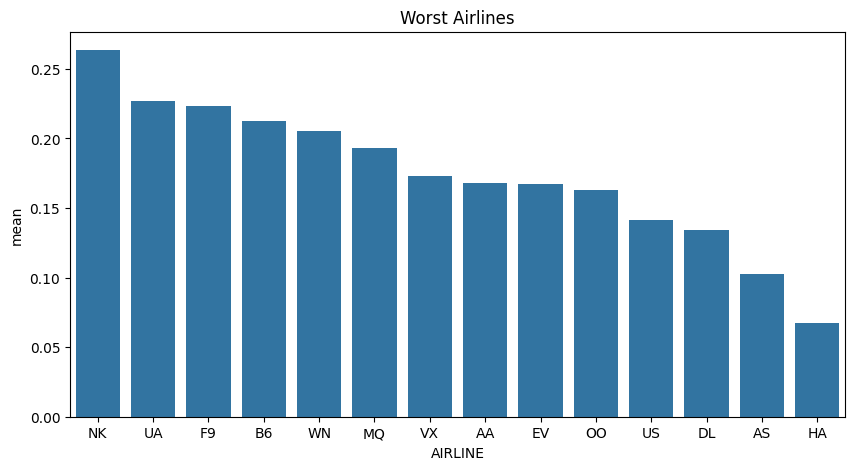

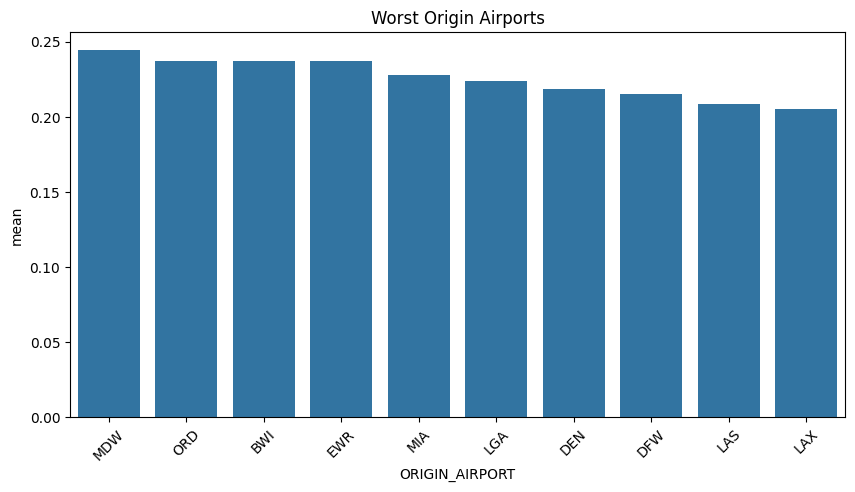

In [5]:

# delay by month
monthly = df.groupby('MONTH')['IS_DELAYED'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=monthly, x='MONTH', y='IS_DELAYED')
plt.title('Delay Rate by Month')
plt.show()

# delay by hour
hourly = df.groupby('SCHED_DEP_HOUR')['IS_DELAYED'].mean().reset_index()
plt.figure(figsize=(12, 5))
sns.barplot(data=hourly, x='SCHED_DEP_HOUR', y='IS_DELAYED')
plt.title('Delay Rate by Hour')
plt.show()

# worst airlines
carrier = df.groupby('AIRLINE')['IS_DELAYED'].agg(['mean','count']).reset_index()
carrier = carrier[carrier['count'] >= 1000].sort_values('mean', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=carrier, x='AIRLINE', y='mean')
plt.title('Worst Airlines')
plt.show()

# worst airports
airport = df.groupby('ORIGIN_AIRPORT')['IS_DELAYED'].agg(['mean','count']).reset_index()
airport = airport[airport['count'] >= 5000].sort_values('mean', ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(data=airport, x='ORIGIN_AIRPORT', y='mean')
plt.title('Worst Origin Airports')
plt.xticks(rotation=45)
plt.show()

In [6]:
df['IS_PEAK_SEASON'] = df['MONTH'].isin([6, 7, 12]).astype(int)

df['IS_LATE_NIGHT'] = df['SCHED_DEP_HOUR'].isin([22, 23, 0]).astype(int)

df['IS_EARLY_MORNING'] = df['SCHED_DEP_HOUR'].isin([5, 6, 7]).astype(int)

print("Peak season:", df[df['IS_PEAK_SEASON']==1]['IS_DELAYED'].mean(), 
      "vs off-peak:", df[df['IS_PEAK_SEASON']==0]['IS_DELAYED'].mean())
print("Late night:", df[df['IS_LATE_NIGHT']==1]['IS_DELAYED'].mean(), 
      "vs other:", df[df['IS_LATE_NIGHT']==0]['IS_DELAYED'].mean())
print("Early morning:", df[df['IS_EARLY_MORNING']==1]['IS_DELAYED'].mean(), 
      "vs other:", df[df['IS_EARLY_MORNING']==0]['IS_DELAYED'].mean())

Peak season: 0.2126708976666351 vs off-peak: 0.16527038155366455
Late night: 0.21676029962546817 vs other: 0.17626756184458187
Early morning: 0.0711281958669797 vs other: 0.19744498889861703


In [7]:
split_idx = int(len(df) * 0.6)
train_df = df.iloc[:split_idx].copy()

print(f"using {len(train_df)} rows for historical stats")

# carrier delay rate
carrier_stats = train_df.groupby('AIRLINE')['IS_DELAYED'].mean()
df['CARRIER_DELAY_RATE'] = df['AIRLINE'].map(carrier_stats)
df['CARRIER_DELAY_RATE'] = df['CARRIER_DELAY_RATE'].fillna(df['IS_DELAYED'].mean())

# origin + month delay rate
origin_monthly = train_df.groupby(['ORIGIN_AIRPORT', 'MONTH'])['IS_DELAYED'].mean()
df['ORIGIN_MONTHLY_DELAY_RATE'] = df.set_index(['ORIGIN_AIRPORT', 'MONTH']).index.map(origin_monthly)
df['ORIGIN_MONTHLY_DELAY_RATE'] = df['ORIGIN_MONTHLY_DELAY_RATE'].fillna(df['IS_DELAYED'].mean())

# route delay rate
route_stats = train_df.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'])['IS_DELAYED'].mean()
df['ROUTE_DELAY_RATE'] = df.set_index(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']).index.map(route_stats)
df['ROUTE_DELAY_RATE'] = df['ROUTE_DELAY_RATE'].fillna(df['IS_DELAYED'].mean())

# correlations
features = [
    'SCHED_DEP_HOUR', 'IS_PEAK_SEASON', 
    'IS_LATE_NIGHT', 'IS_EARLY_MORNING',
    'CARRIER_DELAY_RATE', 
    'ORIGIN_MONTHLY_DELAY_RATE', 'ROUTE_DELAY_RATE',
    'DISTANCE'
]
corr = df[features + ['IS_DELAYED']].corr()['IS_DELAYED'].sort_values(ascending=False)
print(corr)

using 294590 rows for historical stats
IS_DELAYED                   1.000000
SCHED_DEP_HOUR               0.164347
ROUTE_DELAY_RATE             0.154301
ORIGIN_MONTHLY_DELAY_RATE    0.129769
CARRIER_DELAY_RATE           0.094549
IS_PEAK_SEASON               0.054280
IS_LATE_NIGHT                0.018210
DISTANCE                     0.017547
IS_EARLY_MORNING            -0.120547
Name: IS_DELAYED, dtype: float64


In [8]:
import os
os.makedirs('../data/processed', exist_ok=True)

df.to_csv('../data/processed/flights_engineered.csv', index=False)
print(f" saved and shape: {df.shape}")

 saved and shape: (490984, 40)
